# RAG for NVIDIA NVDocs

**Pipeline:**
1. EDA
2. Data Preparation
3. Retrieval Indexes (BM25 + TF-IDF)
4. Feature Engineering
5. Train Ranking Models (Decision Tree, Random Forest, XGBoost, LightGBM)
6. Evaluation & Comparison
7. End-to-End RAG Demo

## Stage 0: Setup & Install Dependencies

In [10]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [11]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

## Stage 1: EDA

In [12]:
from datasets import load_dataset

dataset = load_dataset("nvidia/Retrieval-Synthetic-NVDocs-v1")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 15095
    })
})


In [13]:
display(dataset['train'][0])

{'file_name': ['researchnvidiacom/research.nvidia.com_publication_2022-11_demystifying-map-space-exploration-npus'],
 'text': 'Map Space Exploration is the problem of finding optimized mappings of a Deep Neural Network (DNN) model on an accelerator. It is known to be extremely computationally expensive, and there has been active research looking at both heuristics and learning-based methods to make the problem computationally tractable. However, while there are dozens of mappers out there (all empirically claiming to find better mappings than others), the research community lacks systematic insights on how different search techniques navigate the map-space and how different mapping axes contribute to the accelerator’s performance and efficiency. Such insights are crucial to developing mapping frameworks for emerging DNNs that are increasingly irregular (due to neural architecture search) and sparse, making the corresponding map spaces much more complex. In this work, rather than propos

In [14]:
from datasets import DatasetDict

full_dataset = dataset['train']

train_testval = full_dataset.train_test_split(test_size=0.2, seed=42)

In [15]:
#split into validation (10%) and test (10%)
test_val = train_testval['test'].train_test_split(test_size=0.5, seed=42)

In [16]:
split_dataset = DatasetDict({
    'train': train_testval['train'],
    'validation': test_val['train'],
    'test': test_val['test']
})

In [17]:
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 12076
    })
    validation: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1509
    })
    test: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1510
    })
})


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = split_dataset['train'].to_pandas()

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12076 entries, 0 to 12075
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   file_name              12076 non-null  object
 1   text                   12076 non-null  str   
 2   chunks                 12076 non-null  object
 3   sections_structured    12076 non-null  object
 4   bundle_id              12076 non-null  str   
 5   bundle_members         12076 non-null  object
 6   is_multi_doc           12076 non-null  bool  
 7   document_artifacts     12076 non-null  object
 8   qa_generation          12076 non-null  object
 9   deduplicated_qa_pairs  12076 non-null  object
 10  qa_evaluations         12076 non-null  object
dtypes: bool(1), object(8), str(2)
memory usage: 59.7+ MB


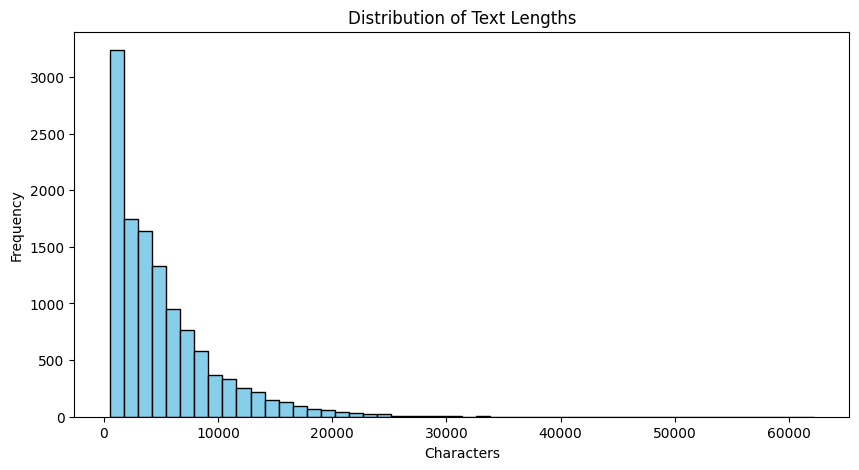

In [22]:
#text length distribution
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Lengths')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

In [23]:
#is_multi_doc distribution
if 'is_multi_doc' in df.columns:
    print(df['is_multi_doc'].value_counts())

is_multi_doc
False    12076
Name: count, dtype: int64


### QA-Chunk Mapping

Each document has chunks and QA pairs. Each QA pair's `segment_ids` field maps to its relevant chunks — this is the **golden label** for training.

In [24]:
#inspect a single document
record = split_dataset['train'][0]

print(f"File: {record['file_name']}")
print(f"Number of chunks: {len(record['chunks'])}")
print(f"Number of QA pairs: {len(record['deduplicated_qa_pairs'])}")

File: ['researchnvidiacom/research.nvidia.com_publication_2022-03_gatspi-gpu-accelerated-gate-level-simulation-power-improvement']
Number of chunks: 1
Number of QA pairs: 7


In [25]:
#first QA pair
qa = record['deduplicated_qa_pairs'][0]
print(f"Question: {qa['question']}")
print(f"Answer: {qa['answer'][:200]}...")
print(f"Query Type: {qa['query_type']}")
print(f"Reasoning Type: {qa['reasoning_type']}")
print(f"Complexity: {qa['question_complexity']}")
print(f"Hop Count: {qa['hop_count']}")
print(f"Relevant Segment IDs: {qa['segment_ids']}")

Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?
Answer: GATSPI leverages GPU acceleration through custom CUDA kernels in PyTorch, enabling a simulation kernel speedup of up to 1668X on a single-GPU system and 7412X on multiple-GPU systems compared to comme...
Query Type: multi_hop
Reasoning Type: factual
Complexity: 5
Hop Count: 1
Relevant Segment IDs: [1]


In [26]:
#preview relevant chunks
chunk_lookup = {c['chunk_id']: c for c in record['chunks']}
for sid in qa['segment_ids']:
    if sid in chunk_lookup:
        c = chunk_lookup[sid]
        print(f"\nChunk ID: {sid}")
        print(f"Text preview: {c['text'][:300]}...")
        print(f"Word count: {c['word_count']}, Sentence count: {c['sentence_count']}")


Chunk ID: 1
Text preview: In this paper, we present GATSPI, a novel GPU accelerated logic gate simulator that enables ultra-fast power estimation for industry sized ASIC designs with millions of gates.. GATSPI is written in PyTorch with custom CUDA kernels for ease of coding and maintainability.. It achieves simulation kerne...
Word count: 140, Sentence count: 5


## Stage 2: Data Preparation

I extract all chunks and QA pairs, then create training triples:
- **Positive**: (question, relevant_chunk, 1) — chunk is in `segment_ids`
- **Negative**: (question, random_chunk, 0) — sampled from other chunks

Note: Random negatives led to subpar NDCG@10 (matching BM25 raw ranking). I later replaced them with BM25∪TF-IDF top-100 candidate pools (hard negatives) in Stage 5 for actual model training.

In [ ]:
from data_prep import extract_all_chunks, extract_qa_pairs, create_relevance_triples, build_chunk_lookup

train_chunks, next_chunk_off, next_doc_off = extract_all_chunks(split_dataset['train'], chunk_offset=0, doc_offset=0)
print(f"Train: {len(train_chunks)} chunks")

Extracting chunks: 100%|██████████| 12076/12076 [00:25<00:00, 473.65it/s]


TypeError: extract_qa_pairs() missing 1 required positional argument: 'chunks_by_doc_and_original_id'

In [ ]:
val_chunks, next_chunk_off, next_doc_off = extract_all_chunks(split_dataset['validation'], chunk_offset=next_chunk_off, doc_offset=next_doc_off)
print(f"Val: {len(val_chunks)} chunks")

In [ ]:
test_chunks, next_chunk_off, next_doc_off = extract_all_chunks(split_dataset['test'], chunk_offset=next_chunk_off, doc_offset=next_doc_off)
print(f"Test: {len(test_chunks)} chunks")

In [ ]:
all_chunks = train_chunks + val_chunks + test_chunks
chunk_by_id, chunk_by_doc_original = build_chunk_lookup(all_chunks)
print(f"Total chunks in corpus: {len(all_chunks)}")
print(f"Unique chunk IDs: {len(chunk_by_id)}, lookup entries: {len(chunk_by_doc_original)}")

In [ ]:
#extract QA pairs (needs chunk lookup for ID mapping)
train_qa = extract_qa_pairs(split_dataset['train'], chunk_by_doc_original, doc_offset=0)
val_qa = extract_qa_pairs(split_dataset['validation'], chunk_by_doc_original, doc_offset=len(split_dataset['train']))
test_qa = extract_qa_pairs(split_dataset['test'], chunk_by_doc_original, doc_offset=len(split_dataset['train']) + len(split_dataset['validation']))
print(f"QA pairs: train={len(train_qa)}, val={len(val_qa)}, test={len(test_qa)}")

train_triples = create_relevance_triples(train_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Train triples: {len(train_triples)} ({train_triples['relevance'].sum()} pos, {(train_triples['relevance']==0).sum()} neg)")

In [ ]:
val_triples = create_relevance_triples(val_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Val triples: {len(val_triples)} ({val_triples['relevance'].sum()} pos, {(val_triples['relevance']==0).sum()} neg)")

### Sanity Checks

In [ ]:
chunk_lookup_all = chunk_by_id

#verify no duplicate chunk IDs
all_ids = [c['chunk_id'] for c in all_chunks]
assert len(all_ids) == len(set(all_ids)), f"DUPLICATE chunk IDs! {len(all_ids)} total vs {len(set(all_ids))} unique"
print(f"✓ All {len(all_ids)} chunk IDs are globally unique")

In [ ]:
#golden chunk_id coverage
for split_name, qa_list in [('train', train_qa), ('val', val_qa), ('test', test_qa)]:
    missing = 0
    total = 0
    for qa in qa_list:
        for cid in qa['chunk_ids']:
            total += 1
            if cid not in chunk_by_id:
                missing += 1
    pct = missing / total * 100 if total > 0 else 0
    if missing == 0:
        print(f"✓ {split_name}: all {total} golden chunk_ids found")
    else:
        print(f"⚠ {split_name}: {missing}/{total} ({pct:.2f}%) chunk_ids missing (dataset noise, skipped)")

In [ ]:
#verify positive triples have correct chunk text
for split_name, triples in [('train', train_triples), ('val', val_triples)]:
    pos_triples = triples[triples['relevance'] == 1]
    bad = 0
    for _, row in pos_triples.iterrows():
        if row['chunk_id'] not in chunk_lookup_all:
            bad += 1
            continue
        actual_text = chunk_lookup_all[row['chunk_id']]['chunk_text']
        if actual_text != row['chunk_text']:
            bad += 1
    assert bad == 0, f"{split_name}: {bad} positive triples have mismatched chunk text!"
    print(f"✓ {split_name}: all {len(pos_triples)} positive triples correct")

In [ ]:
#verify no doc_id overlap between splits
train_docs = set(c['doc_id'] for c in train_chunks)
val_docs = set(c['doc_id'] for c in val_chunks)
test_docs = set(c['doc_id'] for c in test_chunks)
assert not (train_docs & val_docs), f"Train/Val overlap: {train_docs & val_docs}"
assert not (train_docs & test_docs), f"Train/Test overlap: {train_docs & test_docs}"
assert not (val_docs & test_docs), f"Val/Test overlap: {val_docs & test_docs}"
print(f"✓ No doc_id overlap: train={len(train_docs)}, val={len(val_docs)}, test={len(test_docs)}")

In [ ]:
#sample positive triple
sample_pos = train_triples[train_triples['relevance'] == 1].iloc[0]
print(f"\n── Sample positive triple ──")
print(f"  Question: {sample_pos['question'][:120]}...")
print(f"  Chunk ID: {sample_pos['chunk_id']}")
print(f"  Chunk text: {sample_pos['chunk_text'][:120]}...")
print(f"  Relevance: {sample_pos['relevance']}")

In [ ]:
#label balance
for split_name, triples in [('train', train_triples), ('val', val_triples)]:
    n_pos = (triples['relevance'] == 1).sum()
    n_neg = (triples['relevance'] == 0).sum()
    ratio = n_neg / n_pos if n_pos > 0 else float('inf')
    print(f"  {split_name}: {n_pos} positive, {n_neg} negative (ratio ~{ratio:.1f}:1)")

~332 golden segment_ids (out of ~192k chunks) don't resolve to a chunk in the corpus. I skip these during training.

## Stage 3: Build Retrieval Indexes

I build two indexes over the **entire corpus**:

1. **BM25** — sparse lexical scoring based on token overlap
2. **TF-IDF** — TfidfVectorizer + cosine similarity for term importance

These scores become features for the ranking models.

In [ ]:
from retrieval import BM25Index, TfidfIndex

corpus_texts = [c['chunk_text'] for c in all_chunks]
corpus_ids = [c['chunk_id'] for c in all_chunks]
print(f"Corpus size: {len(corpus_texts)} chunks")

In [ ]:
bm25_index = BM25Index(corpus_texts, corpus_ids)

In [ ]:
tfidf_index = TfidfIndex(max_features=50000, ngram_range=(1, 2))
tfidf_index.build_index(corpus_texts, corpus_ids)

In [ ]:
#test retrieval
sample_q = train_qa[0]['question']
print(f"Query: {sample_q}\n")

print("BM25 top-5:")
for chunk_id, score in bm25_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: {score:.4f}")

print("\nTF-IDF top-5:")
for chunk_id, score in tfidf_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: {score:.4f}")

golden_ids = set(train_qa[0]['chunk_ids'])
print(f"\nGolden chunk IDs: {golden_ids}")

## Stage 4: Feature Engineering

For each (question, chunk) pair, I compute:

| Feature | Source |
|---------|--------|
| `bm25_score` | BM25 index |
| `cosine_similarity` | TF-IDF cosine similarity |
| `token_overlap_ratio` | Token set overlap |
| `token_overlap_count` | Token set overlap |
| `question_length` | Question metadata |
| `chunk_word_count` | Chunk metadata |
| `chunk_sentence_count` | Chunk metadata |
| `question_complexity` | QA metadata |
| `hop_count` | QA metadata |
| `qtype_*` | One-hot query type |
| `rtype_*` | One-hot reasoning type |

I use these features (minus low-importance qtype/rtype) to train the ranking models.

In [ ]:
from features import compute_features, get_feature_columns

train_featured = compute_features(train_triples, bm25_index, tfidf_index)
print(f"\nTrain shape: {train_featured.shape}")

In [ ]:
feature_cols = get_feature_columns(train_featured)
print(f"Feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

train_featured[feature_cols].describe().round(3)

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_features = ['bm25_score', 'cosine_similarity', 'token_overlap_ratio',
                'question_length', 'chunk_word_count', 'question_complexity']

for ax, feat in zip(axes.flat, key_features):
    for rel, color, label in [(1, 'green', 'Relevant'), (0, 'red', 'Not Relevant')]:
        subset = train_featured[train_featured['relevance'] == rel][feat]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Relevance', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier as _RFC

#quick RF for feature importance
_rf_importance = _RFC(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
_rf_importance.fit(train_featured[feature_cols].values, train_featured['relevance'].values)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': _rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:\n")
print(importance_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(x='feature', y='importance', kind='barh', ax=ax, legend=False)
ax.invert_yaxis()
ax.set_title('Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
#low-importance features to drop
drop_threshold = 0.01
low_importance = importance_df[importance_df['importance'] < drop_threshold]['feature'].tolist()
print(f"\nFeatures below {drop_threshold} threshold:")
for f in low_importance:
    print(f"  - {f}")

## Stage 5: Train Ranking Models

**Key insight**: Models must train on the **same distribution** they see at evaluation. At eval time, models re-rank BM25∪TF-IDF top-100 candidates (all with high retrieval scores). Training on random negatives (low BM25) causes models to learn a trivial "high BM25 = relevant" rule.

**Solution**: Build training data from candidate pools (hard negatives aka negatives with high BM25 scores)

**Models:**
1. **BM25 Baseline** — rank by BM25 score directly
2. **TF-IDF Baseline** — rank by TF-IDF cosine similarity
3. **Decision Tree** — single tree classifier
4. **Random Forest** — ensemble of trees
5. **XGBoost Ranker** — `rank:ndcg` objective
6. **LightGBM Ranker** — LambdaMART

In [ ]:
import importlib
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import evaluate as _eval_mod; importlib.reload(_eval_mod)
from evaluate import prepare_candidates, evaluate_from_candidates, candidates_to_training_data, print_evaluation

In [ ]:
#drop low-importance qtype/rtype features
drop_features = [c for c in feature_cols if c.startswith('qtype_') or c.startswith('rtype_')]
feature_cols = [c for c in feature_cols if c not in drop_features]
print(f"Dropped {len(drop_features)} features: {drop_features}")
print(f"Keeping {len(feature_cols)}: {feature_cols}")

Our original approach was to take the training questions and score them against all the chunks. This got to be a large compute/memory problem quick --> 82k questions x 192k chunks = ~10B entries...

I tried a few different approaches with batching, however none really worked. In the end, I decided to go with subsampling the training data and taking 10k samples. 

In an ideal world, and when implementing this in production I would want to explore a few approaches:
1. Having an inverted index so we can have a small set of candidates docs in training that match between query-document
2. Using OAI, Cohere text embeddings to map the chunks in a vector space. Then we would be able to map the user query in a vector space, then finding the closest top neighbors / results / chunks

In [ ]:
chunk_lookup = chunk_by_id

#subsample training questions for faster candidate computation
TRAIN_SAMPLE_SIZE = 10000
rng = np.random.RandomState(42)
if len(train_qa) > TRAIN_SAMPLE_SIZE:
    train_qa_sample = [train_qa[i] for i in rng.choice(len(train_qa), TRAIN_SAMPLE_SIZE, replace=False)]
    print(f"Subsampled train_qa: {len(train_qa)} → {len(train_qa_sample)}")
else:
    train_qa_sample = train_qa

#precompute train candidates (BM25 ∪ TF-IDF top-100)
print("Building train candidate pools...")
train_candidates = prepare_candidates(train_qa_sample, bm25_index, tfidf_index,
                                       chunk_lookup, feature_cols, candidate_k=100)
print(f"Train: {len(train_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in train_candidates]):.0f} candidates each")

#precompute val candidates (use all — val is already small)
print("\nBuilding val candidate pools...")
val_candidates = prepare_candidates(val_qa, bm25_index, tfidf_index,
                                     chunk_lookup, feature_cols, candidate_k=100)
print(f"Val: {len(val_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in val_candidates]):.0f} candidates each")

### 5a. Training Data from Candidates & Baselines

In [ ]:
#convert candidates to training arrays
X_train, y_train, train_groups = candidates_to_training_data(train_candidates, feature_cols)
X_val, y_val, val_groups = candidates_to_training_data(val_candidates, feature_cols)

print(f"Training: X={X_train.shape}, pos={y_train.sum():.0f}, neg={(y_train==0).sum():.0f}")
print(f"Validation: X={X_val.shape}, pos={y_val.sum():.0f}, neg={(y_val==0).sum():.0f}")
print(f"Train groups: {len(train_groups)}, avg size: {train_groups.mean():.0f}")
print(f"Val groups: {len(val_groups)}, avg size: {val_groups.mean():.0f}")

In [ ]:
#BM25 baseline
bm25_val_metrics, _ = evaluate_from_candidates(val_candidates, model=None)
print_evaluation(bm25_val_metrics, "BM25 Baseline (Val)")

#TF-IDF baseline
tfidf_val_metrics, _ = evaluate_from_candidates(val_candidates, model='tfidf')
print_evaluation(tfidf_val_metrics, "TF-IDF Baseline (Val)")

### 5b. Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

In [ ]:
dt_val_metrics, _ = evaluate_from_candidates(val_candidates, dt_model)
print_evaluation(dt_val_metrics, "Decision Tree (Val)")

dt_importance = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(dt_importance.head(10))

### 5c. Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

In [ ]:
rf_val_metrics, _ = evaluate_from_candidates(val_candidates, rf_model)
print_evaluation(rf_val_metrics, "Random Forest (Val)")

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_importance.head(10))

### 5d. XGBoost Ranker

XGBoost `rank:ndcg` directly optimizes NDCG. Requires a `group` parameter for query boundaries.

In [ ]:
import xgboost as xgb

print(f"Train groups: {len(train_groups)}, Val groups: {len(val_groups)}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

In [ ]:
xgb_model = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
)

In [ ]:
xgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    verbose=50
)

In [ ]:
xgb_val_metrics, _ = evaluate_from_candidates(val_candidates, xgb_model)
print_evaluation(xgb_val_metrics, "XGBoost Ranker (Val)")

### 5e. LightGBM Ranker (LambdaMART)

In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRanker(
    objective='lambdarank',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

In [ ]:
lgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    eval_at=[5, 10, 20],
)

In [ ]:
lgb_val_metrics, _ = evaluate_from_candidates(val_candidates, lgb_model)
print_evaluation(lgb_val_metrics, "LightGBM Ranker (Val)")

## Stage 6: Model Comparison & Test Evaluation

I compare all models on validation, pick the best by NDCG@10, then run final evaluation on the held-out test set.

In [ ]:
all_val_metrics = {
    'BM25 Baseline': bm25_val_metrics,
    'TF-IDF Cosine': tfidf_val_metrics,
    'Decision Tree': dt_val_metrics,
    'Random Forest': rf_val_metrics,
    'XGBoost Ranker': xgb_val_metrics,
    'LightGBM Ranker': lgb_val_metrics,
}

comparison_df = pd.DataFrame(all_val_metrics).T.round(4)
display(comparison_df)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['NDCG@10', 'Recall@10', 'MRR']
for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].sort_values(ascending=True)
    colors = ['#2ecc71' if v == values.max() else '#3498db' for v in values]
    values.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric, fontsize=14)
    ax.set_xlabel('Score')
    for i, v in enumerate(values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.suptitle('Model Comparison (Validation)', fontsize=16)
plt.tight_layout()
plt.show()

### Final Test Evaluation

For each test question, I retrieve top-100 from BM25 ∪ top-100 from TF-IDF, then re-rank with the best model. 

In [ ]:
test_candidates = prepare_candidates(test_qa, bm25_index, tfidf_index,
                                      chunk_lookup, feature_cols, candidate_k=100)
print(f"Test: {len(test_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in test_candidates]):.0f} candidates each")

In [ ]:
best_model_name = str(comparison_df['NDCG@10'].idxmax())
print(f"Best model (Val NDCG@10): {best_model_name}")

In [ ]:
model_objects = {
    'BM25 Baseline': None,
    'TF-IDF Cosine': 'tfidf',
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost Ranker': xgb_model,
    'LightGBM Ranker': lgb_model,
}
best_model_obj = model_objects[best_model_name]

In [ ]:
bm25_test_metrics, bm25_meta = evaluate_from_candidates(test_candidates, model=None)
print_evaluation(bm25_test_metrics, "BM25 Baseline (Test)")

In [ ]:
tfidf_test_metrics, tfidf_meta = evaluate_from_candidates(test_candidates, model='tfidf')
print_evaluation(tfidf_test_metrics, "TF-IDF Baseline (Test)")

In [ ]:
print(f"Evaluating {best_model_name}...")
best_test_metrics, best_meta = evaluate_from_candidates(test_candidates, best_model_obj)
print_evaluation(best_test_metrics, f"{best_model_name} (Test)")

In [ ]:
test_comparison_df = pd.DataFrame({
    'BM25 Baseline': bm25_test_metrics,
    'TF-IDF Cosine': tfidf_test_metrics,
    best_model_name: best_test_metrics,
}).T.round(4)

display(test_comparison_df)

In [ ]:
#candidate pool diagnostics
print(f"Avg candidates/question: {best_meta['n_candidates'].mean():.0f}")
print(f"Avg golden chunks/question: {best_meta['n_golden'].mean():.1f}")
print(f"Golden recall in pool: {(best_meta['golden_in_candidates'] / best_meta['n_golden']).mean():.4f}")

In [ ]:
#breakdown by query type
print(f"=== {best_model_name} — By Query Type ===\n")
for qtype in best_meta['query_type'].unique():
    mask = best_meta['query_type'] == qtype
    subset = [c for c, m in zip(test_candidates, mask) if m]
    if len(subset) > 0:
        metrics, _ = evaluate_from_candidates(subset, best_model_obj, k_values=[10])
        print(f"  {qtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

In [ ]:
#breakdown by reasoning type
print(f"=== {best_model_name} — By Reasoning Type ===\n")
for rtype in best_meta['reasoning_type'].unique():
    mask = best_meta['reasoning_type'] == rtype
    subset = [c for c, m in zip(test_candidates, mask) if m]
    if len(subset) > 0:
        metrics, _ = evaluate_from_candidates(subset, best_model_obj, k_values=[10])
        print(f"  {rtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

## Stage 7: End-to-End RAG Demo

Given a question:
1. Retrieve top-50 candidates from BM25 ∪ TF-IDF
2. Compute features for each (question, candidate) pair
3. Re-rank with the best model
4. Return top-5 chunks

In [ ]:
from features import compute_text_overlap

def rag_retrieve(question, tfidf_index, bm25_index, model, feature_cols,
                 candidate_k=50, final_k=5):
    """Retrieve and re-rank chunks for a question."""
    bm25_candidates = dict(bm25_index.top_k(question, k=candidate_k))
    tfidf_candidates = dict(tfidf_index.top_k(question, k=candidate_k))

    #merge candidate sets
    seen = set()
    merged = []
    for cid in list(bm25_candidates.keys()) + list(tfidf_candidates.keys()):
        if cid not in seen:
            seen.add(cid)
            merged.append(cid)

    #baselines: rank by raw score
    if model is None:
        results = [(cid, chunk_lookup[cid]['chunk_text'], bm25_candidates.get(cid, 0.0)) for cid in merged]
        results.sort(key=lambda x: x[2], reverse=True)
        return results[:final_k]
    elif model == 'tfidf':
        results = [(cid, chunk_lookup[cid]['chunk_text'], tfidf_candidates.get(cid, 0.0)) for cid in merged]
        results.sort(key=lambda x: x[2], reverse=True)
        return results[:final_k]

    #build feature matrix
    rows = []
    for chunk_id in merged:
        chunk = chunk_lookup[chunk_id]
        overlap = compute_text_overlap(question, chunk['chunk_text'])
        row = {
            'bm25_score': bm25_candidates.get(chunk_id, 0.0),
            'cosine_similarity': tfidf_candidates.get(chunk_id, 0.0),
            'token_overlap_ratio': overlap['token_overlap_ratio'],
            'token_overlap_count': overlap['token_overlap_count'],
            'question_length': len(question.split()),
            'chunk_word_count': chunk['word_count'],
            'chunk_sentence_count': chunk['sentence_count'],
            'question_complexity': 3,
            'hop_count': 1,
        }
        rows.append((chunk_id, chunk['chunk_text'], row))

    feature_rows = pd.DataFrame([r[2] for r in rows])
    for col in feature_cols:
        if col not in feature_rows.columns:
            feature_rows[col] = 0
    feature_rows = feature_rows[feature_cols]

    #re-rank
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(feature_rows.values)[:, 1]
    else:
        scores = model.predict(feature_rows.values)

    results = [(rows[i][0], rows[i][1], float(scores[i])) for i in range(len(rows))]
    results.sort(key=lambda x: x[2], reverse=True)
    return results[:final_k]

In [ ]:
#demo
demo_question = test_qa[0]['question']
demo_golden = set(test_qa[0]['chunk_ids'])

print(f"Query: {demo_question}\n")
print(f"Golden chunks: {demo_golden}\n")

results = rag_retrieve(demo_question, tfidf_index, bm25_index, best_model_obj, feature_cols)

print(f"=== Top-5 ({best_model_name}) ===\n")
for rank, (chunk_id, text, score) in enumerate(results, 1):
    is_relevant = "✓ RELEVANT" if chunk_id in demo_golden else ""
    print(f"Rank {rank}: {chunk_id} (score={score:.4f}) {is_relevant}")
    print(f"  {text[:150]}...")